--- PLL System Simulation Results ---
Divider Ratio (N) : 10.0
Loop Bandwidth    : 1.34 MHz
Phase Margin      : 60.1 Degrees
-------------------------------------


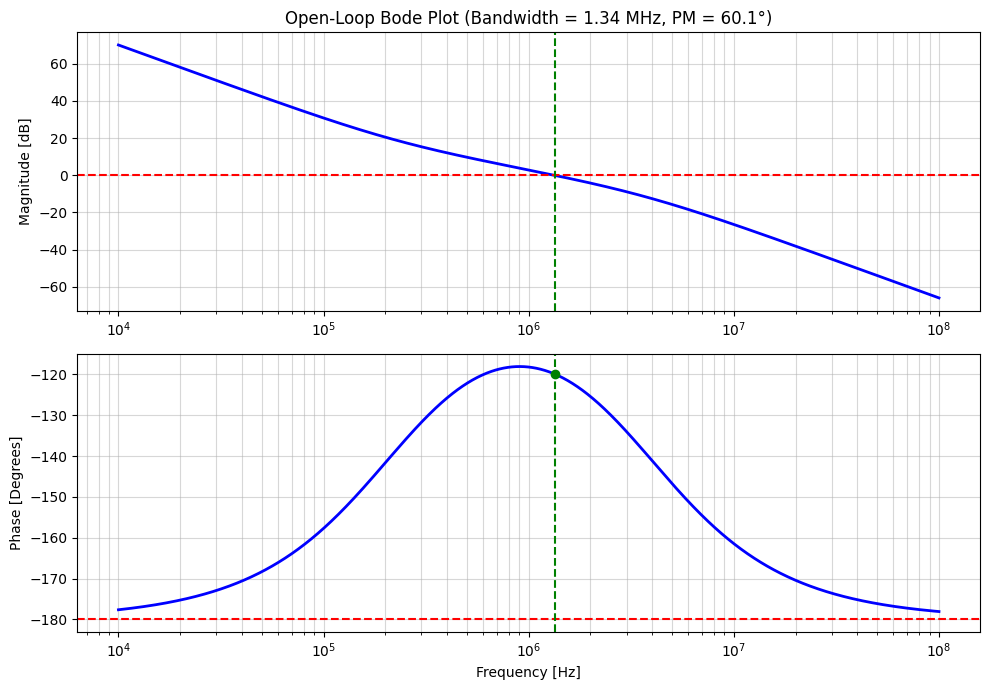

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ==========================================
# 1. PLL System Parameters
# ==========================================
F_ref = 24e6          # Reference Frequency (24 MHz)
F_out = 240e6         # Target Output Frequency (240 MHz)
N = F_out / F_ref     # Feedback Divider Ratio (10)

I_cp = 100e-6         # Charge Pump Current (100 uA)
K_vco_hz = 200e6      # VCO Gain in Hz/V (200 MHz/V)

# ==========================================
# 2. Loop Filter Passive Components
# ==========================================
# Tweak these values to change bandwidth and phase margin
R2 = 4700             # Series Resistor (4.7 kOhms)
C1 = 150e-12          # Series Capacitor (150 pF)
C3 = 10e-12           # Parallel Ripple Capacitor (10 pF)

# ==========================================
# 3. Transfer Function Derivation
# ==========================================
# K_pd = I_cp / (2 * pi)
# K_vco_rad = K_vco_hz * (2 * pi)
# Product of gains (2*pi cancels out): K_loop = I_cp * K_vco_hz / N
K_loop = (I_cp * K_vco_hz) / N

# Loop Filter Impedance Z(s) = (s*R2*C1 + 1) / [s * (s*R2*C1*C3 + C1 + C3)]
# Open Loop H(s) = (K_loop / s) * Z(s)
# Combine into numerator and denominator polynomials for Scipy (s^3, s^2, s^1, s^0)

num = [K_loop * R2 * C1, K_loop]
den = [R2 * C1 * C3, (C1 + C3), 0, 0]

# Create the continuous-time LTI system
H_open = signal.TransferFunction(num, den)

# ==========================================
# 4. Frequency Analysis (Bode Plot)
# ==========================================
# Generate frequency array from 10 kHz to 100 MHz
f_hz = np.logspace(4, 8, 1000) 
w_rad = 2 * np.pi * f_hz       

# Calculate Bode plot
w, mag_db, phase_deg = signal.bode(H_open, w=w_rad)
f_plot = w / (2 * np.pi) # Convert rad/s back to Hz for plotting

# Find Loop Bandwidth (Unity Gain Frequency where Magnitude = 0 dB)
# We find the index where mag_db is closest to 0
cross_idx = np.argmin(np.abs(mag_db))
f_bw = f_plot[cross_idx]
phase_margin = 180 + phase_deg[cross_idx]

print("--- PLL System Simulation Results ---")
print(f"Divider Ratio (N) : {N}")
print(f"Loop Bandwidth    : {f_bw / 1e6:.2f} MHz")
print(f"Phase Margin      : {phase_margin:.1f} Degrees")
print("-------------------------------------")

# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 7))

# Magnitude Plot
plt.subplot(2, 1, 1)
plt.semilogx(f_plot, mag_db, 'b', linewidth=2)
plt.axhline(0, color='r', linestyle='--')
plt.axvline(f_bw, color='g', linestyle='--')
plt.title(f'Open-Loop Bode Plot (Bandwidth = {f_bw/1e6:.2f} MHz, PM = {phase_margin:.1f}°)')
plt.ylabel('Magnitude [dB]')
plt.grid(True, which="both", ls="-", alpha=0.5)

# Phase Plot
plt.subplot(2, 1, 2)
plt.semilogx(f_plot, phase_deg, 'b', linewidth=2)
plt.axhline(-180, color='r', linestyle='--')
plt.axvline(f_bw, color='g', linestyle='--')
plt.plot(f_bw, phase_deg[cross_idx], 'go') # Mark the phase margin point
plt.ylabel('Phase [Degrees]')
plt.xlabel('Frequency [Hz]')
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()


--- 3.3V PLL System Simulation Results ---
Divider Ratio (N) : 10.0
Loop Bandwidth    : 1.39 MHz
Phase Margin      : 65.1 Degrees
Loop Filter Area  : C1=100.0pF, C3=5.0pF
------------------------------------------


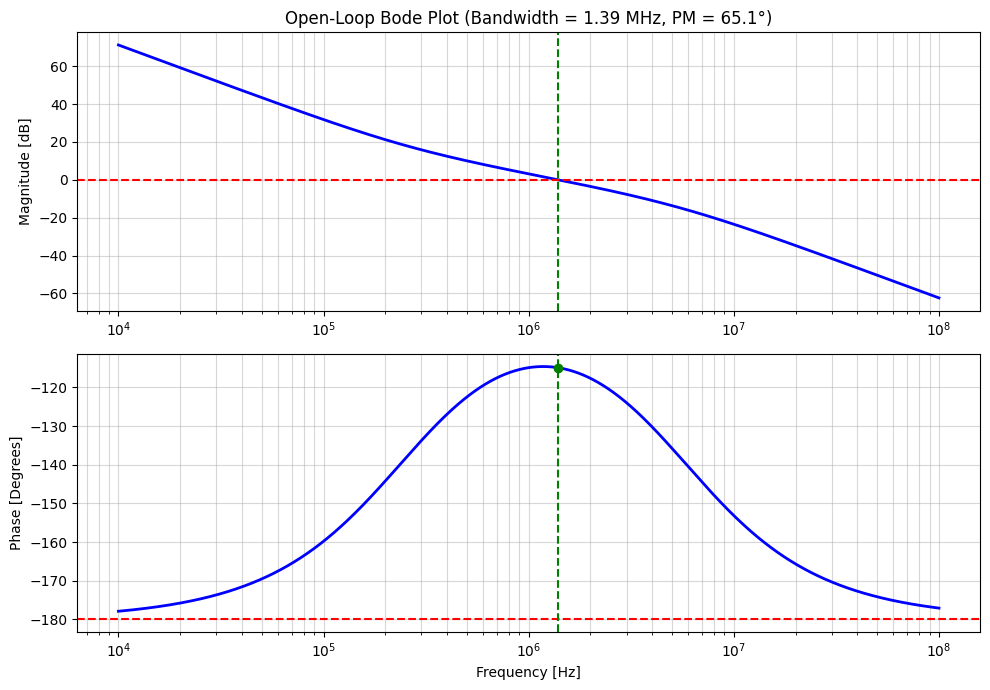

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ==========================================
# 1. NEW PLL System Parameters (3.3V Spec)
# ==========================================
F_ref = 24e6          # Reference Frequency (24 MHz)
F_out = 240e6         # Target Output Frequency (240 MHz)
N = F_out / F_ref     # Feedback Divider Ratio (10)

I_cp = 100e-6         # Charge Pump Current (100 uA)
K_vco_hz = 150e6      # UPDATED: VCO Gain for 3.3V (150 MHz/V)

# ==========================================
# 2. Recalculated Loop Filter Components
# ==========================================
# Tuned to achieve ~1.5 MHz Bandwidth and ~60° Phase Margin
R2 = 6200             # Series Resistor increased to 6.2 kOhms
C1 = 100e-12          # Series Capacitor (100 pF)
C3 = 5e-12            # Parallel Ripple Capacitor (5 pF)

# ==========================================
# 3. Transfer Function Derivation
# ==========================================
# K_loop = I_cp * K_vco_hz / N
K_loop = (I_cp * K_vco_hz) / N

# Loop Filter Impedance Z(s) = (s*R2*C1 + 1) / [s * (s*R2*C1*C3 + C1 + C3)]
# Open Loop H(s) = (K_loop / s) * Z(s)
num = [K_loop * R2 * C1, K_loop]
den = [R2 * C1 * C3, (C1 + C3), 0, 0]

# Create the continuous-time LTI system
H_open = signal.TransferFunction(num, den)

# ==========================================
# 4. Frequency Analysis (Bode Plot)
# ==========================================
f_hz = np.logspace(4, 8, 2000) 
w_rad = 2 * np.pi * f_hz       

w, mag_db, phase_deg = signal.bode(H_open, w=w_rad)
f_plot = w / (2 * np.pi) 

# Find Loop Bandwidth (Unity Gain Frequency where Magnitude = 0 dB)
cross_idx = np.argmin(np.abs(mag_db))
f_bw = f_plot[cross_idx]
phase_margin = 180 + phase_deg[cross_idx]

print("--- 3.3V PLL System Simulation Results ---")
print(f"Divider Ratio (N) : {N}")
print(f"Loop Bandwidth    : {f_bw / 1e6:.2f} MHz")
print(f"Phase Margin      : {phase_margin:.1f} Degrees")
print(f"Loop Filter Area  : C1={C1*1e12}pF, C3={C3*1e12}pF")
print("------------------------------------------")

# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 7))

# Magnitude Plot
plt.subplot(2, 1, 1)
plt.semilogx(f_plot, mag_db, 'b', linewidth=2)
plt.axhline(0, color='r', linestyle='--')
plt.axvline(f_bw, color='g', linestyle='--')
plt.title(f'Open-Loop Bode Plot (Bandwidth = {f_bw/1e6:.2f} MHz, PM = {phase_margin:.1f}°)')
plt.ylabel('Magnitude [dB]')
plt.grid(True, which="both", ls="-", alpha=0.5)

# Phase Plot
plt.subplot(2, 1, 2)
plt.semilogx(f_plot, phase_deg, 'b', linewidth=2)
plt.axhline(-180, color='r', linestyle='--')
plt.axvline(f_bw, color='g', linestyle='--')
plt.plot(f_bw, phase_deg[cross_idx], 'go') 
plt.ylabel('Phase [Degrees]')
plt.xlabel('Frequency [Hz]')
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

Maximum Jitter Peaking: 1.19 dB


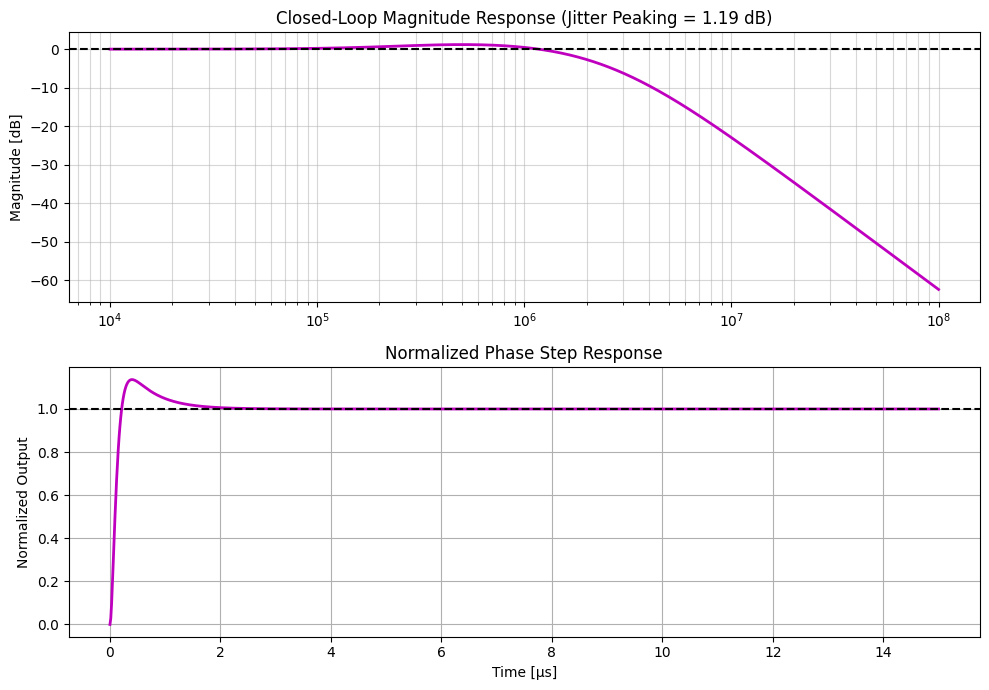

In [2]:
# ==========================================
# 6. Closed-Loop Transfer Function
# ==========================================
# H_closed(s) = H_open(s) / (1 + H_open(s))
# Since H_open = num / den, H_closed = num / (den + num)

num_closed = num
den_closed = [
    den[0],                 # s^3 term
    den[1],                 # s^2 term
    den[2] + num[0],        # s^1 term
    den[3] + num[1]         # s^0 term
]

H_closed = signal.TransferFunction(num_closed, den_closed)

# ==========================================
# 7. Closed-Loop Frequency Response (Jitter Peaking)
# ==========================================
w_cl, mag_cl_db, phase_cl_deg = signal.bode(H_closed, w=w_rad)

# Calculate Jitter Peaking
peak_db = np.max(mag_cl_db)
print(f"Maximum Jitter Peaking: {peak_db:.2f} dB")

# ==========================================
# 8. Time-Domain Step Response
# ==========================================
# Simulate the transient response for 15 microseconds
t_in = np.linspace(0, 15e-6, 1000)
t_out, y_out = signal.step(H_closed, T=t_in)

# ==========================================
# 9. Plotting the Closed-Loop Behavior
# ==========================================
plt.figure(figsize=(10, 7))

# Closed-Loop Magnitude Plot
plt.subplot(2, 1, 1)
plt.semilogx(f_plot, mag_cl_db, 'm', linewidth=2)
plt.axhline(0, color='k', linestyle='--')
plt.title(f'Closed-Loop Magnitude Response (Jitter Peaking = {peak_db:.2f} dB)')
plt.ylabel('Magnitude [dB]')
plt.grid(True, which="both", ls="-", alpha=0.5)

# Step Response Plot
plt.subplot(2, 1, 2)
plt.plot(t_out * 1e6, y_out, 'm', linewidth=2)
plt.axhline(1.0, color='k', linestyle='--')
plt.title('Normalized Phase Step Response')
plt.ylabel('Normalized Output')
plt.xlabel('Time [μs]')
plt.grid(True)

plt.tight_layout()
plt.show()

--- Self-Biased PLL Silicon Layout Targets ---
Target Damping Factor (zeta) : 1.0
Target BW/REF Ratio          : 0.1
----------------------------------------------
Charge Pump Multiplier (x)   : 1.00 (Charge Pump current vs Buffer Bias)
Resistor Multiplier (y)      : 0.79 (Diode-connected PMOS size vs Buffer Load)
Capacitance Ratio (C1/CB)    : 253.30
----------------------------------------------
How to use this in GF180 Layout:
1. If your VCO's total internal capacitance (CB) is estimated at 200 fF...
2. Your loop filter capacitor (C1) must be exactly 253.30 * 200 fF = 50.66 pF.


<>:67: SyntaxWarning: invalid escape sequence '\z'
<>:67: SyntaxWarning: invalid escape sequence '\o'
<>:67: SyntaxWarning: invalid escape sequence '\z'
<>:67: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_604934/3343793995.py:67: SyntaxWarning: invalid escape sequence '\z'
  plt.title(f'Theoretical Phase Step Response ($\zeta$={zeta_target}, $\omega_N/\omega_{{REF}}$={bw_ratio_target})')
/tmp/ipykernel_604934/3343793995.py:67: SyntaxWarning: invalid escape sequence '\o'
  plt.title(f'Theoretical Phase Step Response ($\zeta$={zeta_target}, $\omega_N/\omega_{{REF}}$={bw_ratio_target})')


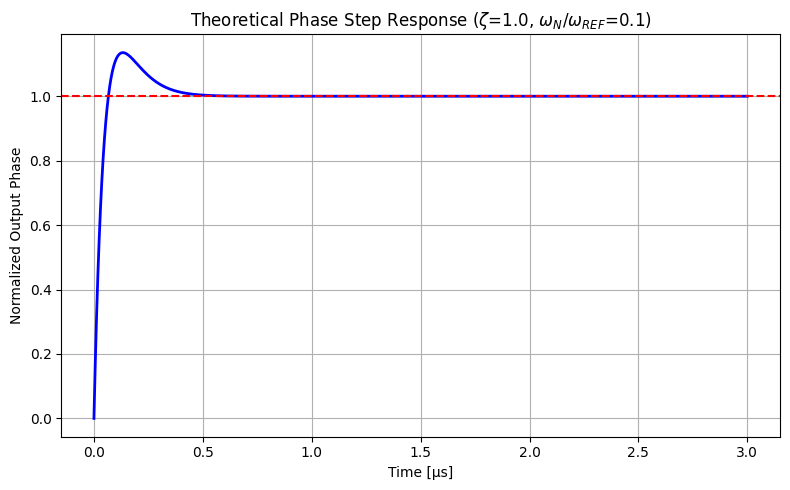

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ==========================================
# 1. System Targets
# ==========================================
N = 10.0               # Feedback Divider Ratio (240MHz / 24MHz)
zeta_target = 1.0      # Target Damping Factor (1.0 = Critically Damped)
bw_ratio_target = 0.1  # Target Loop Bandwidth to Reference Freq Ratio (wN / wREF)
                       # Note: 0.1 (1/10th) is the maximum safe theoretical limit for stability.

# ==========================================
# 2. Design Choices (The "Knobs")
# ==========================================
# x = Charge Pump Current Multiplier
# Ich = x * (2 * I_D) where 2*I_D is the buffer bias current.
# We choose x=1 as a baseline so the charge pump perfectly mirrors the buffer.
x = 1.0                

# ==========================================
# 3. Ratio Calculations (Maneatis Equations)
# ==========================================
# Equation 22: (wN / wREF) = (x * N / 2*pi) * sqrt(CB / C1)
# Solving for the Capacitance Ratio (C1 / CB):
sqrt_CB_C1 = bw_ratio_target * (2 * np.pi) / (x * N)
C1_CB_ratio = 1.0 / (sqrt_CB_C1**2)

# Equation 21: zeta = (y / 4) * sqrt(x / N) * sqrt(C1 / CB)
# y = Resistor Multiplier (R = y / 2gm)
# Solving for y:
y = (4 * zeta_target) / (np.sqrt(x / N) * np.sqrt(C1_CB_ratio))

# ==========================================
# 4. Print Layout Specifications
# ==========================================
print("--- Self-Biased PLL Silicon Layout Targets ---")
print(f"Target Damping Factor (zeta) : {zeta_target}")
print(f"Target BW/REF Ratio          : {bw_ratio_target}")
print("----------------------------------------------")
print(f"Charge Pump Multiplier (x)   : {x:.2f} (Charge Pump current vs Buffer Bias)")
print(f"Resistor Multiplier (y)      : {y:.2f} (Diode-connected PMOS size vs Buffer Load)")
print(f"Capacitance Ratio (C1/CB)    : {C1_CB_ratio:.2f}")
print("----------------------------------------------")
print("How to use this in GF180 Layout:")
print(f"1. If your VCO's total internal capacitance (CB) is estimated at 200 fF...")
print(f"2. Your loop filter capacitor (C1) must be exactly {C1_CB_ratio:.2f} * 200 fF = {C1_CB_ratio * 200e-15 * 1e12:.2f} pF.")

# ==========================================
# 5. Theoretical Step Response Visualization
# ==========================================
# For a 24 MHz reference and a target ratio of 0.1, the effective bandwidth is 2.4 MHz
w_n_effective = bw_ratio_target * (24e6 * 2 * np.pi) 

# Ideal 2nd Order PLL Closed-Loop Transfer Function
# H(s) = (2*zeta*wN*s + wN^2) / (s^2 + 2*zeta*wN*s + wN^2)
num = [2 * zeta_target * w_n_effective, w_n_effective**2]
den = [1, 2 * zeta_target * w_n_effective, w_n_effective**2]
sys = signal.TransferFunction(num, den)

t_in = np.linspace(0, 3e-6, 1000)
t_out, y_out = signal.step(sys, T=t_in)

plt.figure(figsize=(8, 5))
plt.plot(t_out * 1e6, y_out, 'b-', linewidth=2)
plt.axhline(1.0, color='r', linestyle='--')
plt.title(f'Theoretical Phase Step Response ($\zeta$={zeta_target}, $\omega_N/\omega_{{REF}}$={bw_ratio_target})')
plt.ylabel('Normalized Output Phase')
plt.xlabel('Time [μs]')
plt.grid(True)
plt.tight_layout()
plt.show()